In [0]:
%pip install statsmodels scikit-learn pmdarima

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np

# Read flu data
flu_spark = spark.read.csv(
    "/Volumes/workspace/default/databricks-pharma/FluNet WHO.csv",
    header=True,
    inferSchema=True
)
flu_data = flu_spark.toPandas()

# Read sales data
sales_spark = spark.read.csv(
    "/Volumes/workspace/default/databricks-pharma/Sales /salesweekly.csv",
    header=True,
    inferSchema=True
)
sales_wk = sales_spark.toPandas()

print(f"Flu rows: {len(flu_data)}")
print(f"Sales rows: {len(sales_wk)}")

Flu rows: 189843
Sales rows: 302


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import and execute method for suppressing warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [0]:
flu_data.head().T

,0,1,2,3,4
WHOREGION,AMR,AMR,AMR,AMR,AMR
FLUSEASON,YR,YR,YR,YR,YR
HEMISPHERE,NH,NH,NH,NH,NH
ITZ,FLU_CNT_AMC,FLU_CNT_AMC,FLU_CNT_AMC,FLU_CNT_AMC,FLU_CNT_AMC
COUNTRY_CODE,ABW,ABW,ABW,ABW,ABW
COUNTRY_AREA_TERRITORY,Aruba,Aruba,Aruba,Aruba,Aruba
ISO_WEEKSTARTDATE,2017-01-02,2017-01-09,2017-01-16,2017-01-23,2017-01-30
ISO_YEAR,2017,2017,2017,2017,2017
ISO_WEEK,1,2,3,4,5
MMWR_WEEKSTARTDATE,2017-01-01,2017-01-08,2017-01-15,2017-01-22,2017-01-29


In [0]:
flu_data.isnull().sum()

WHOREGION                       1
FLUSEASON                    3667
HEMISPHERE                   4153
ITZ                          4293
COUNTRY_CODE                 6187
COUNTRY_AREA_TERRITORY       6393
ISO_WEEKSTARTDATE            6496
ISO_YEAR                     7043
ISO_WEEK                     7067
MMWR_WEEKSTARTDATE           7117
MMWR_YEAR                    7123
MMWR_WEEK                    7125
ORIGIN_SOURCE                7128
SPEC_PROCESSED_NB           19866
SPEC_RECEIVED_NB           126222
AH1N12009                   54488
AH1                         88803
AH3                         37486
AH5                        130419
AH7N9                      165633
ANOTSUBTYPED                42937
ANOTSUBTYPABLE             171988
AOTHER_SUBTYPE             141968
AOTHER_SUBTYPE_DETAILS     182332
INF_A                       30710
BVIC_2DEL                  179552
BVIC_3DEL                  180717
BVIC_NODEL                  68106
BVIC_DELUNK                180319
BYAM          

In [0]:
flu_data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
189838    False
189839    False
189840    False
189841    False
189842    False
Length: 189843, dtype: bool

In [0]:
flu_data['ISO_WEEKSTARTDATE'] = pd.to_datetime(flu_data['ISO_WEEKSTARTDATE'],errors='coerce')

In [0]:
cols_needed = ['COUNTRY_CODE', 'ISO_WEEKSTARTDATE', 'INF_ALL']
flu_data = flu_data[cols_needed]
flu_data.head()

,COUNTRY_CODE,ISO_WEEKSTARTDATE,INF_ALL
0,ABW,2017-01-02,11.0
1,ABW,2017-01-09,NaN
2,ABW,2017-01-16,3.0
3,ABW,2017-01-23,1.0
4,ABW,2017-01-30,NaN


In [0]:
flu_data = flu_data.groupby(['COUNTRY_CODE', 'ISO_WEEKSTARTDATE']).agg({
    'INF_ALL': 'sum'
}).reset_index()

In [0]:
df_usa=flu_data[flu_data['COUNTRY_CODE'] == 'USA']

In [0]:
df_usa = df_usa.groupby('ISO_WEEKSTARTDATE')['INF_ALL'].sum().reset_index()

Remaining duplicates in USA index: 0


<Axes: title={'center': 'Cleaned USA Flu Signal (Aggregate)'}, xlabel='ISO_WEEKSTARTDATE'>

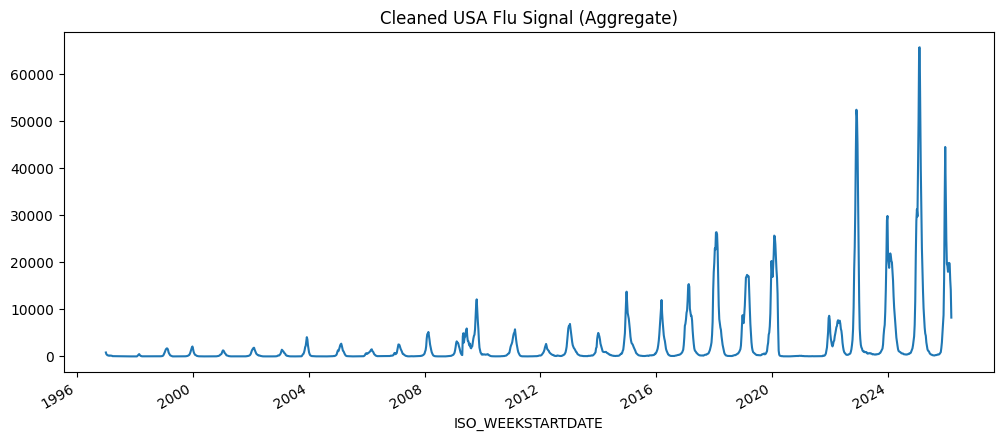

In [0]:
# 1. Filter for USA after the global sum
df_usa = flu_data[flu_data['COUNTRY_CODE'] == 'USA'].copy()
df_usa['ISO_WEEKSTARTDATE'] = pd.to_datetime(df_usa['ISO_WEEKSTARTDATE'])
df_usa.set_index('ISO_WEEKSTARTDATE', inplace=True)
df_usa.sort_index(inplace=True)

# 2. Check for Duplicates AGAIN (Should be 0 now)
print(f"Remaining duplicates in USA index: {df_usa.index.duplicated().sum()}")

# 3. The Final Plot (Should be ONE clean line now)
df_usa['INF_ALL'].plot(figsize=(12,5), title="Cleaned USA Flu Signal (Aggregate)")


In [0]:
df_usa = df_usa.rename(columns={'INF_ALL': 'flu_index'})

In [0]:
# 1. Calculate how many weeks SHOULD exist vs how many DO exist
expected_weeks = (df_usa.index.max() - df_usa.index.min()).days / 7
actual_weeks = len(df_usa)

print(f"Data spans from {df_usa.index.min().year} to {df_usa.index.max().year}")
print(f"Expected Weeks: {int(expected_weeks)}")
print(f"Actual Weeks in Data: {actual_weeks}")
print(f"Missing Weeks: {int(expected_weeks - actual_weeks)}")


Data spans from 1996 to 2026
Expected Weeks: 1523
Actual Weeks in Data: 1384
Missing Weeks: 139


In [0]:
# 1. Force the weekly frequency to reveal the NaNs
df_usa_gap = df_usa.asfreq('W')

# 2. Find the dates of the missing weeks
missing_dates = df_usa_gap[df_usa_gap['flu_index'].isna()].index
print(f"First 5 missing weeks: \n{missing_dates[:5]}")
print(f"Last 5 missing weeks: \n{missing_dates[-5:]}")


First 5 missing weeks: 
DatetimeIndex(['1997-01-05', '1997-01-12', '1997-01-19', '1997-01-26',
               '1997-02-02'],
              dtype='datetime64[ns]', name='ISO_WEEKSTARTDATE', freq='W-SUN')
Last 5 missing weeks: 
DatetimeIndex(['2026-02-08', '2026-02-15', '2026-02-22', '2026-03-01',
               '2026-03-08'],
              dtype='datetime64[ns]', name='ISO_WEEKSTARTDATE', freq='W-SUN')


In [0]:
# Focus on the 'Modern Era' of high-fidelity reporting
df_final = df_usa_gap.loc['2015-01-01':].copy()

# Fill the small remaining gaps in this window
df_final['flu_index'] = df_final['flu_index'].interpolate(method='linear')

print(f"Remaining NaNs in the Modern Window: {df_final['flu_index'].isna().sum()}")


Remaining NaNs in the Modern Window: 584


In [0]:
# Focus on the 'Modern Era' of high-fidelity reporting
df_final = df_usa_gap.loc['2015-01-01':].copy()

# Fill the small remaining gaps in this window
df_final['flu_index'] = df_final['flu_index'].interpolate(method='linear')

print(f"Remaining NaNs in the Modern Window: {df_final['flu_index'].isna().sum()}")


Remaining NaNs in the Modern Window: 584


In [0]:
# 1. Find the last week that actually has a value > 0
last_real_week = df_usa[df_usa['flu_index'] > 0].index.max()
print(f"The last reliable data point is: {last_real_week}")

# 2. Re-filter your 'Modern Window' based on that reality
df_final = df_usa.loc['2015-01-01':last_real_week].asfreq('W')

# 3. Now check NaNs again
print(f"Remaining NaNs in the ACTUAL reported window: {df_final['flu_index'].isna().sum()}")


The last reliable data point is: 2026-03-09 00:00:00
Remaining NaNs in the ACTUAL reported window: 583


In [0]:
import pandas as pd
import numpy as np

# 1. Force the flu_index column to be numeric
# 'coerce' turns any non-numeric junk into NaN so it doesn't crash
df_usa['flu_index'] = pd.to_numeric(df_usa['flu_index'], errors='coerce')

# 2. Now run the "Real Data Count" audit safely
modern_window = df_usa.loc['2015-01-01':]
real_data_count = (modern_window['flu_index'] > 0).sum()

print(f"Total weeks with actual flu cases since 2015: {real_data_count}")
print(f"Total weeks in the 2015-2026 window: {len(modern_window)}")


Total weeks with actual flu cases since 2015: 584
Total weeks in the 2015-2026 window: 584


In [0]:
df_usa['flu_index'] = df_usa['flu_index'].rolling(3, min_periods=1).mean()
df_usa['flu_lag_2'] = df_usa['flu_index'].shift(2)
df_usa = df_usa.dropna()

In [0]:
df_usa = df_usa.loc['2015-01-01':]

<Axes: xlabel='ISO_WEEKSTARTDATE'>

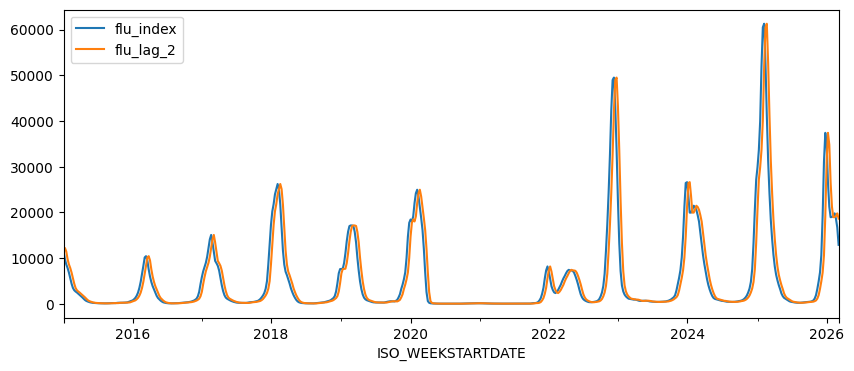

In [0]:
df_usa.plot(figsize=(10,4))

Text(0.5, 1.0, 'Leading Indicator: 2-Week Lag (Supply Chain Lead Time)')

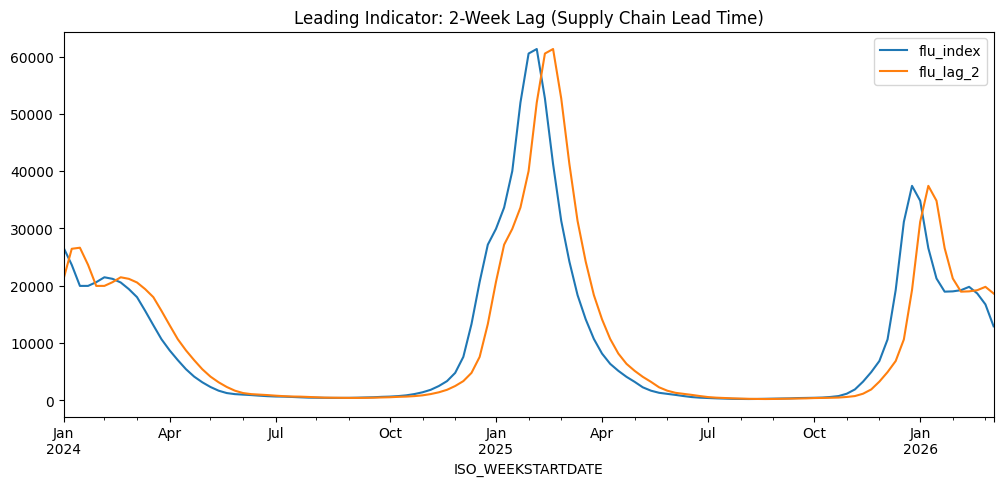

In [0]:
# Zoom in on the last 2 years so the 2-week gap is visible to the eye
df_usa.loc['2024-01-01':][['flu_index', 'flu_lag_2']].plot(figsize=(12,5))
plt.title("Leading Indicator: 2-Week Lag (Supply Chain Lead Time)")


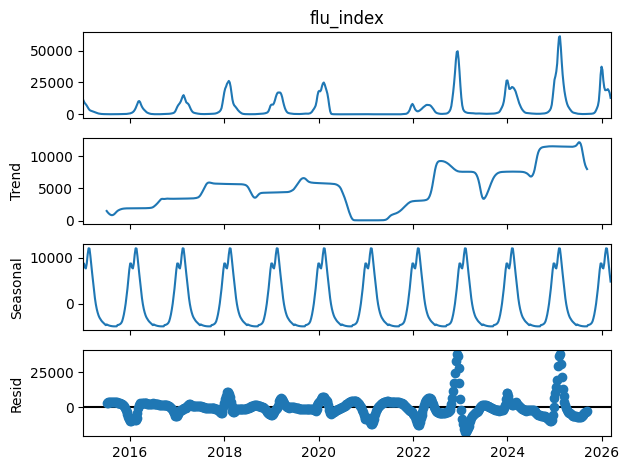

In [0]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Run decomposition on your clean 2015-2026 window
result = seasonal_decompose(df_usa['flu_index'], model='additive', period=52)
result.plot()
plt.show()


In [0]:
sales_wk.shape

(302, 9)

In [0]:
sales_wk.isnull().sum()

datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

In [0]:
sales_wk['date'] = pd.to_datetime(sales_wk['datum'], errors='coerce')

In [0]:
sales_wk = sales_wk.set_index('datum').sort_index()

In [0]:
sales_wk = sales_wk.set_index('date')


In [0]:
sales_wk = sales_wk.sort_index()

In [0]:
# keep only needed columns
df_sales = sales_wk[['R03', 'R06', 'N02BE']]

# rename
df_sales = df_sales.rename(columns={
    'R03': 'R03_sales',
    'R06': 'R06_sales',
    'N02BE': 'N02BE_sales'
})

In [0]:
df_sales = df_sales.loc['2015-01-01':]

In [0]:
df_sales = df_sales.interpolate(method='linear')


In [0]:
df_sales['resp_index'] = df_sales['R03_sales'] + df_sales['R06_sales']

In [0]:
df_sales.index = df_sales.index.to_series().dt.to_period('W').dt.to_timestamp()
df_usa.index   = df_usa.index.to_series().dt.to_period('W').dt.to_timestamp()

In [0]:
df_sales = df_sales.sort_index()
df_usa   = df_usa.sort_index()

In [0]:
df_combined = df_sales.join(df_usa[['flu_index','flu_lag_2']], how='inner')

In [0]:
df_combined.corr()

,R03_sales,R06_sales,N02BE_sales,resp_index,flu_index,flu_lag_2
R03_sales,1.000000,-0.151913,0.414735,0.879969,0.274166,0.262566
R06_sales,-0.151913,1.000000,-0.471042,0.335840,-0.138247,0.006731
N02BE_sales,0.414735,-0.471042,1.000000,0.168846,0.226641,0.115942
resp_index,0.879969,0.335840,0.168846,1.000000,0.194831,0.253455
flu_index,0.274166,-0.138247,0.226641,0.194831,1.000000,0.925357
flu_lag_2,0.262566,0.006731,0.115942,0.253455,0.925357,1.000000


In [0]:
# 1. The "Business Truth" Correlation
sales_flu_corr = df_combined['R03_sales'].corr(df_combined['flu_index'])
sales_lag_corr = df_combined['R03_sales'].corr(df_combined['flu_lag_2'])

print(f"--- Demand Sensing Proof ---")
print(f"Sales vs. Current Flu (Lag 0): {sales_flu_corr:.3f}")
print(f"Sales vs. Engineered Lead Time (Lag 2): {sales_lag_corr:.3f}")


--- Demand Sensing Proof ---
Sales vs. Current Flu (Lag 0): 0.274
Sales vs. Engineered Lead Time (Lag 2): 0.263


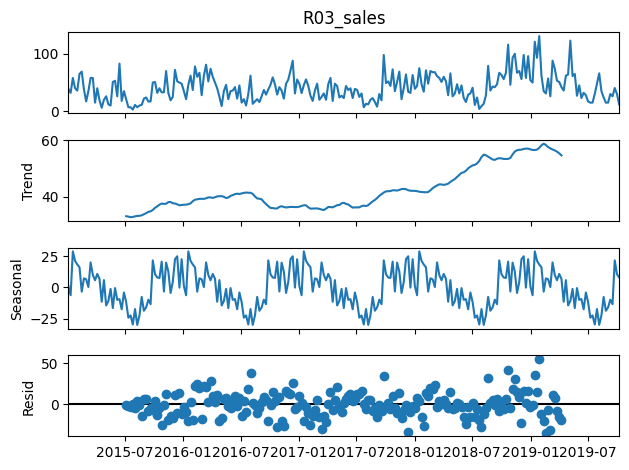

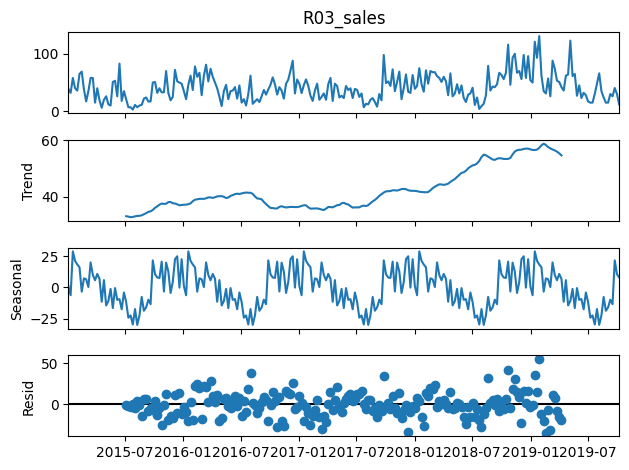

In [0]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_combined['R03_sales'], model='additive', period=52)
decomp.plot()

In [0]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_combined['R03_sales'])
print("p-value:", result[1])

p-value: 0.013805843181299288


In [0]:
pip install pmdarima

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Split ---
# df_combined is sorted weekly; check total rows first
print(f"Total weeks: {len(df_combined)}")

split_idx = int(len(df_combined) * 0.80)   # 80/20 split
df_train = df_combined.iloc[:split_idx]
df_test  = df_combined.iloc[split_idx:]

print(f"Train: {df_train.index[0].date()} → {df_train.index[-1].date()}  ({len(df_train)} weeks)")
print(f"Test : {df_test.index[0].date()}  → {df_test.index[-1].date()}   ({len(df_test)} weeks)")

Total weeks: 249
Train: 2015-01-05 → 2018-10-22  (199 weeks)
Test : 2018-10-29  → 2019-10-07   (50 weeks)


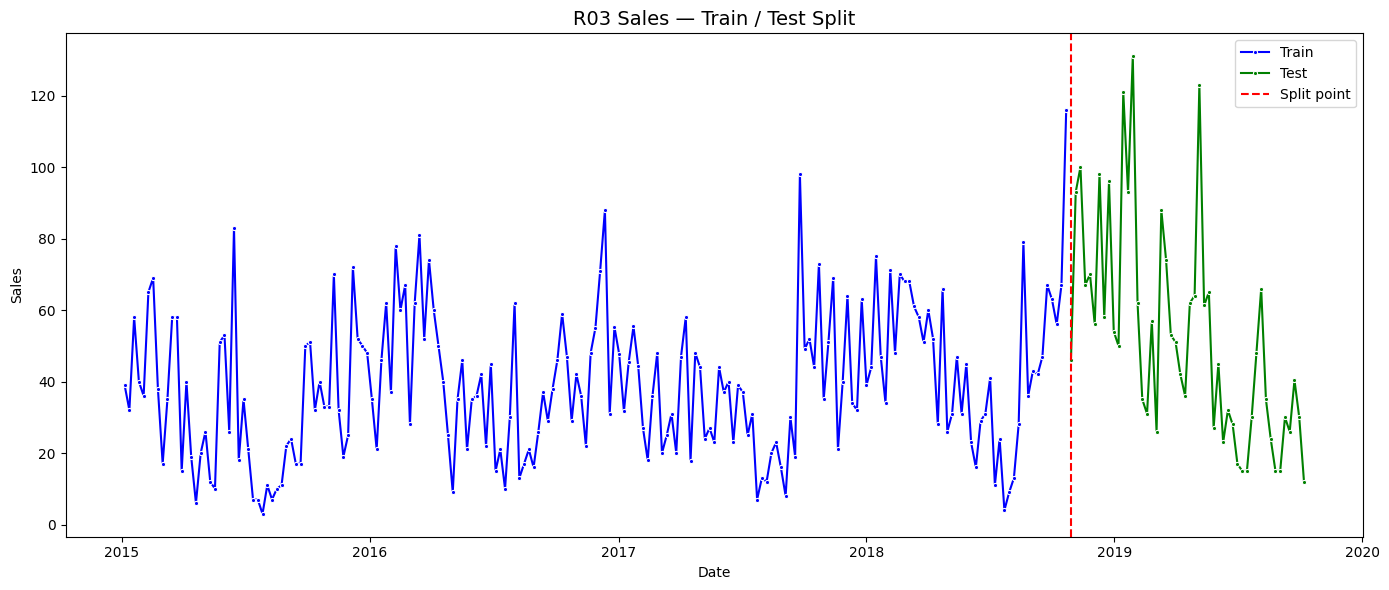

In [0]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=df_train, x=df_train.index, y='R03_sales',
             marker='o', markersize=3, color='blue', label='Train')

sns.lineplot(data=df_test, x=df_test.index, y='R03_sales',
             marker='o', markersize=3, color='green', label='Test')

plt.axvline(df_test.index[0], color='red', linestyle='--', linewidth=1.5, label='Split point')
plt.title('R03 Sales — Train / Test Split', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

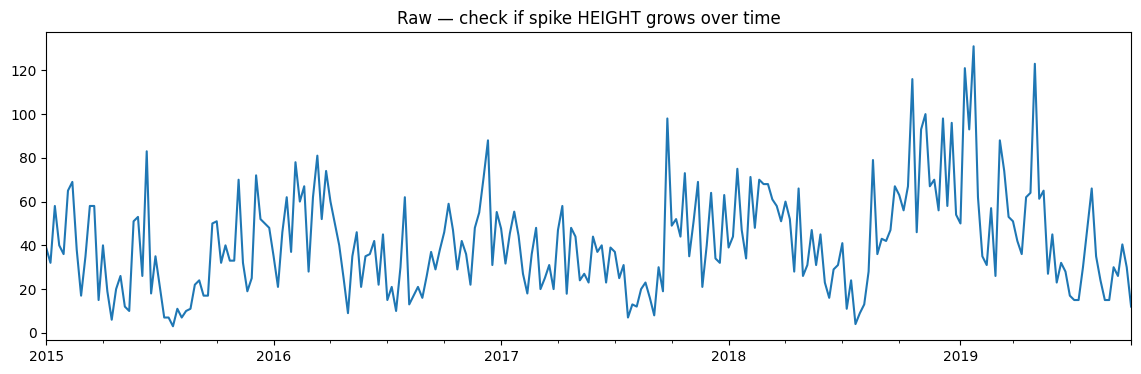

In [0]:
import matplotlib.pyplot as plt

df_combined['R03_sales'].plot(figsize=(14,4), title='Raw — check if spike HEIGHT grows over time')
plt.show()

ADF p-value after Log+Diff: 0.0000


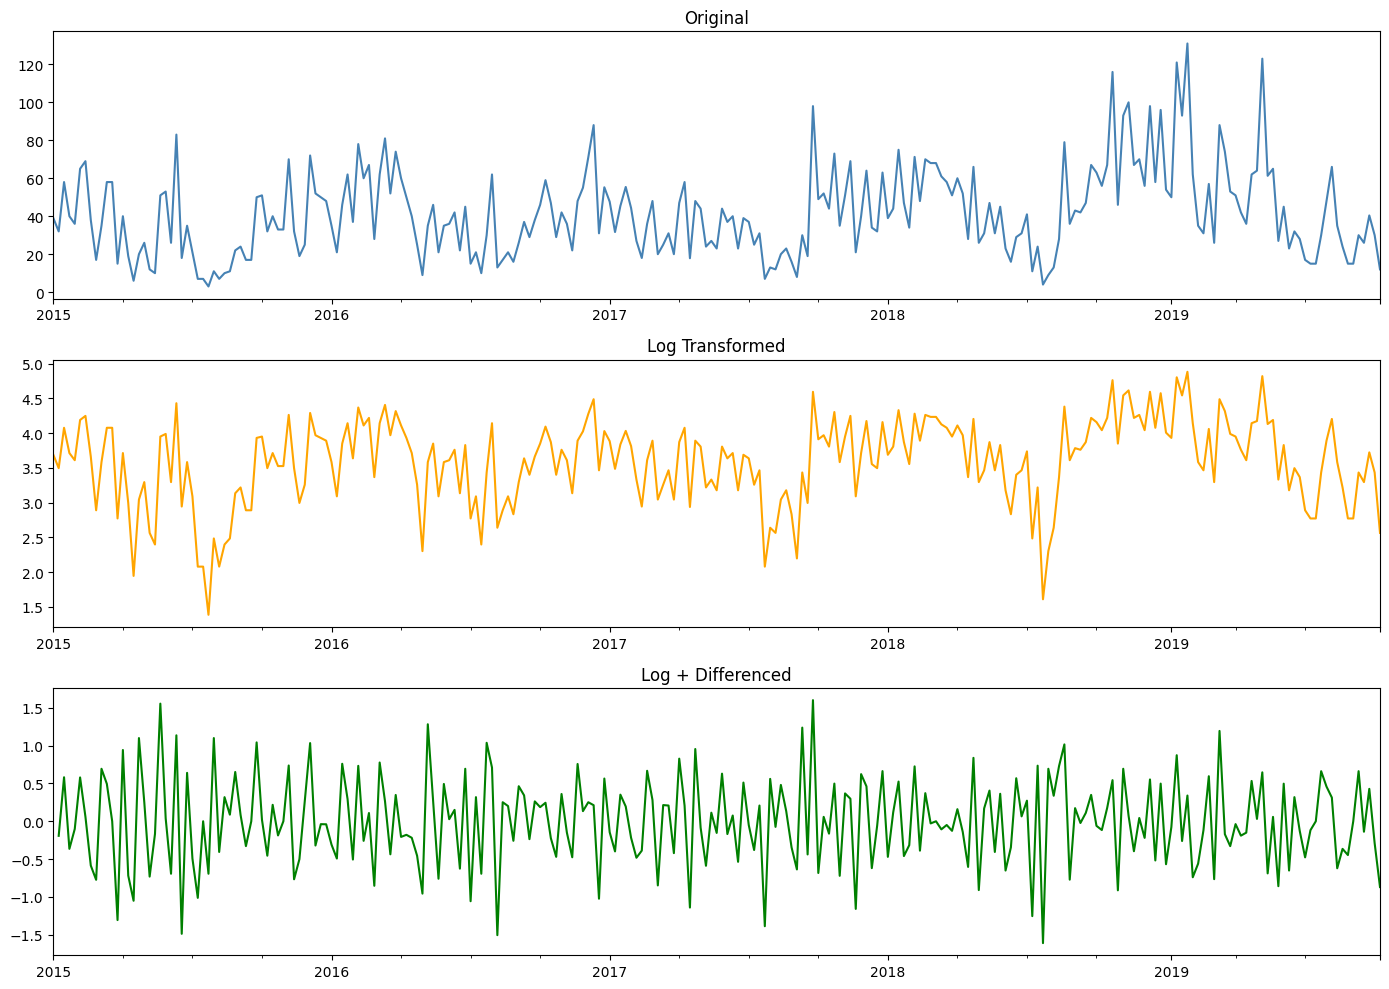

In [0]:
import numpy as np

# Step 1: Log transform (stabilizes variance)
df_combined['R03_log'] = np.log1p(df_combined['R03_sales'])

# Step 2: First difference (removes trend)
df_combined['R03_log_diff'] = df_combined['R03_log'].diff(1).dropna()

# Step 3: Re-check ADF on transformed series
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_combined['R03_log_diff'].dropna())
print(f"ADF p-value after Log+Diff: {result[1]:.4f}")
# Target: p < 0.05 ✅

# Step 4: Visual confirmation
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
df_combined['R03_sales'].plot(ax=axes[0], title='Original', color='steelblue')
df_combined['R03_log'].plot(ax=axes[1], title='Log Transformed', color='orange')
df_combined['R03_log_diff'].plot(ax=axes[2], title='Log + Differenced', color='green')
plt.tight_layout()
plt.show()

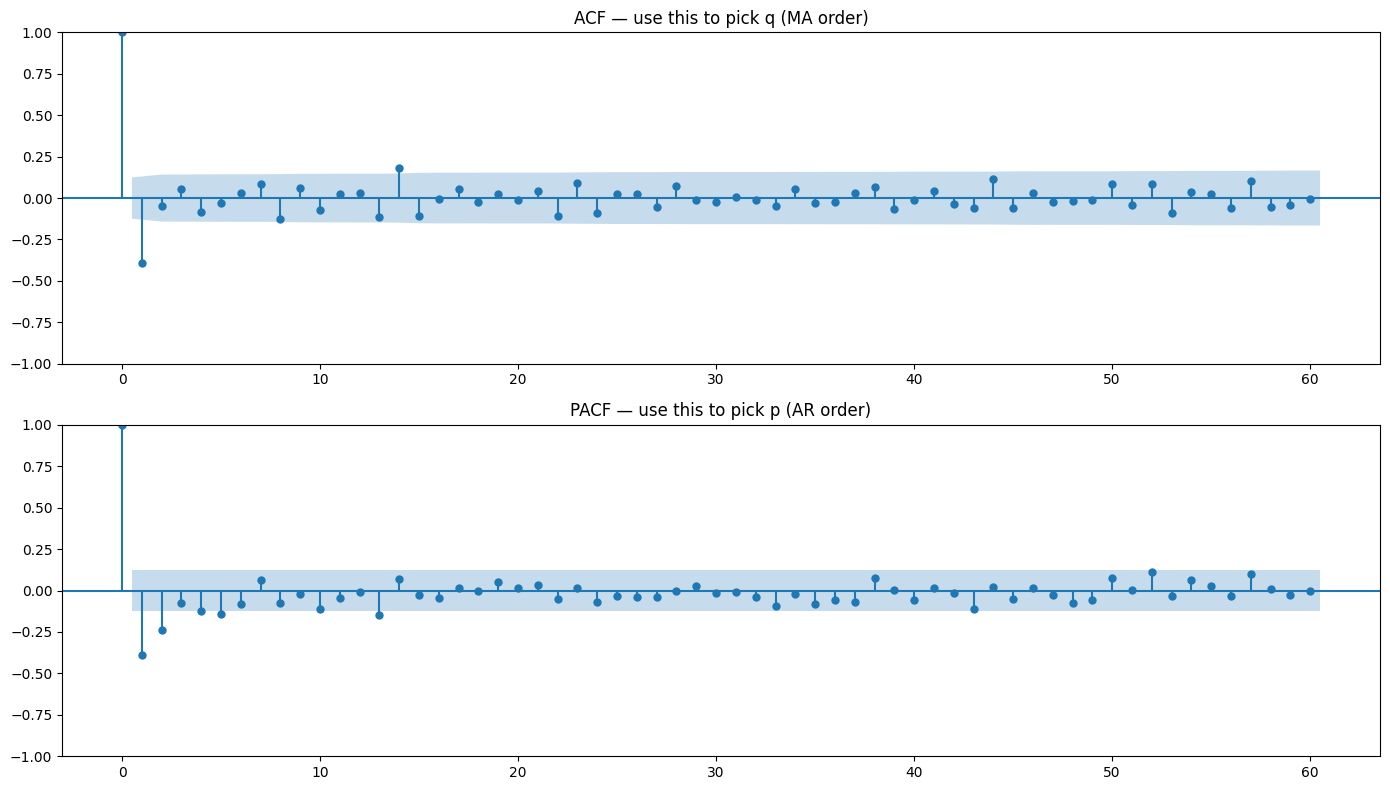

In [0]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df_combined['R03_log_diff'].dropna(),  lags=60, ax=axes[0],
         title='ACF — use this to pick q (MA order)')
plot_pacf(df_combined['R03_log_diff'].dropna(), lags=60, ax=axes[1],
          title='PACF — use this to pick p (AR order)')

plt.tight_layout()
plt.show()

In [0]:
from pmdarima import auto_arima
import numpy as np

model = auto_arima(
    np.log1p(df_train['R03_sales']),
    X=df_train[['flu_index']],
    d=1, D=1,
    seasonal=True, m=52,
    stepwise=True,
    max_p=2, max_q=2,
    max_P=1, max_Q=1,
    max_order=4,
    trace=True,
    suppress_warnings=True,
    error_action='ignore',
    n_jobs=1              # ← add this for Databricks stability
)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[52]             : AIC=276.088, Time=86.30 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=349.456, Time=1.84 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=305.976, Time=25.31 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=305.432, Time=13.31 sec
 ARIMA(2,1,2)(0,1,1)[52]             : AIC=272.755, Time=91.55 sec
 ARIMA(2,1,2)(0,1,0)[52]             : AIC=298.765, Time=4.90 sec
 ARIMA(2,1,2)(1,1,0)[52]             : AIC=282.355, Time=69.10 sec
 ARIMA(1,1,2)(0,1,1)[52]             : AIC=270.613, Time=73.11 sec
 ARIMA(1,1,2)(0,1,0)[52]             : AIC=295.544, Time=4.48 sec
 ARIMA(1,1,2)(1,1,1)[52]             : AIC=267.699, Time=63.14 sec
 ARIMA(1,1,2)(1,1,0)[52]             : AIC=277.259, Time=59.76 sec
 ARIMA(0,1,2)(1,1,1)[52]             : AIC=262.393, Time=53.51 sec
 ARIMA(0,1,2)(0,1,1)[52]             : AIC=272.251, Time=39.30 sec
 ARIMA(0,1,2)(1,1,0)[52]             : AIC=274.551, Time=32.49 sec
 ARIMA(0,1,2)(0,1,0)[5

In [0]:
# Bridge cell — connect auto_arima result to SARIMAX
print("auto_arima selected order:", model.order)
print("auto_arima selected seasonal order:", model.seasonal_order)
print("Proceeding with SARIMAX using these orders + MLflow tracking...")

auto_arima selected order: (0, 1, 2)
auto_arima selected seasonal order: (1, 1, 1, 52)
Proceeding with SARIMAX using these orders + MLflow tracking...


In [0]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

y_train = np.log1p(df_train['R03_sales'])
X_train = df_train[['flu_index']]

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2, 1, 1),              # ← p=2, d=1, q=1
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          R03_sales   No. Observations:                  199
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 52)   Log Likelihood                 -91.473
Date:                            Fri, 10 Apr 2026   AIC                            196.946
Time:                                    06:25:31   BIC                            214.598
Sample:                                01-05-2015   HQIC                           204.071
                                     - 10-22-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
flu_index  -1.103e-05    4.4e-05     -0.251      0.802   -9.72e-05    7.51e-05
ar.L1         -0.2622      0.221   

In [0]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Fix 1: Scale flu_index so coefficient is meaningful
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[['flu_index']])
X_test_scaled  = scaler.transform(df_test[['flu_index']])

# Fix 2: Reduce seasonal complexity — drop Q term (1,1,0,52)
y_train = np.log1p(df_train['R03_sales'])

final_model = SARIMAX(
    y_train,
    exog=X_train_scaled,
    order=(1, 1, 1),              # back to AIC winner
    seasonal_order=(1, 1, 0, 52), # ← drop seasonal MA (Q=0)
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = final_model.fit(disp=False)
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                           R03_sales   No. Observations:                  199
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                 -70.705
Date:                             Fri, 10 Apr 2026   AIC                            151.411
Time:                                     06:25:57   BIC                            164.074
Sample:                                 01-05-2015   HQIC                           156.523
                                      - 10-22-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0466      0.103     -0.453      0.651      -0.249       0.155
ar.L1          0.3109      

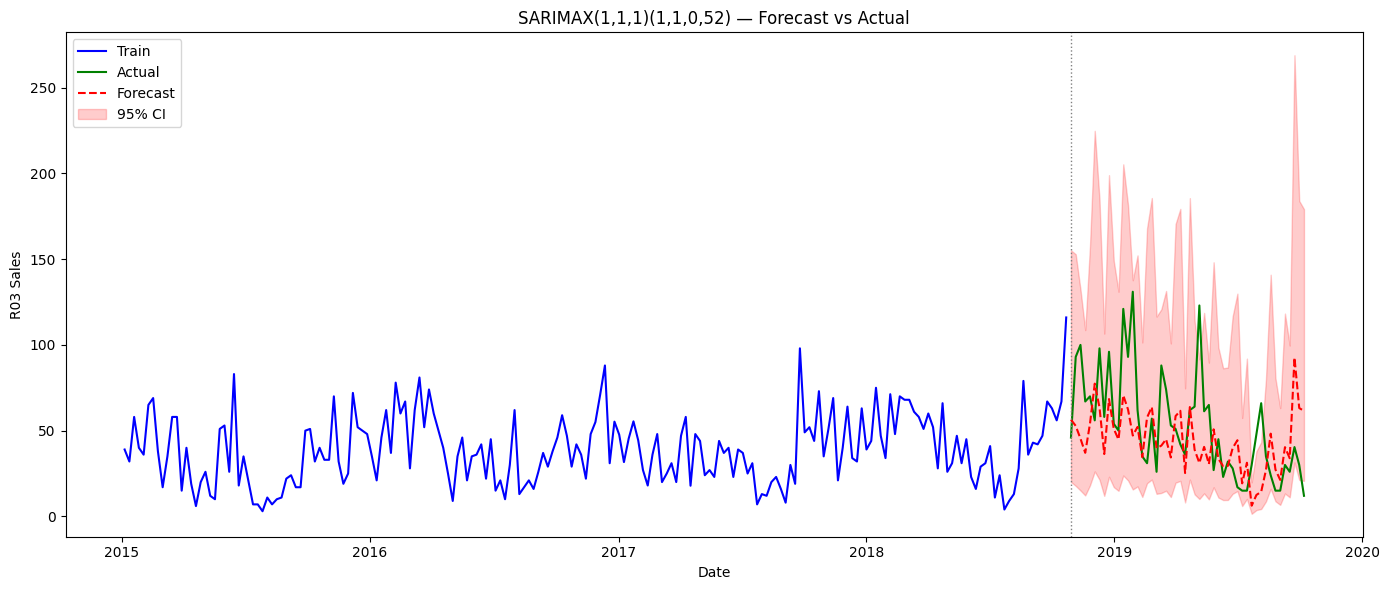

MAPE  : 55.16%
Accuracy: 44.84%


In [0]:
# Forecast on test set
forecast = results.get_forecast(
    steps=len(df_test),
    exog=X_test_scaled
)

# Back-transform from log
pred_log = forecast.predicted_mean
pred_ci  = forecast.conf_int()

pred_sales = np.expm1(pred_log)
ci_lower   = np.expm1(pred_ci.iloc[:, 0])
ci_upper   = np.expm1(pred_ci.iloc[:, 1])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['R03_sales'], color='blue',  label='Train')
plt.plot(df_test.index,  df_test['R03_sales'],  color='green', label='Actual')
plt.plot(df_test.index,  pred_sales,            color='red',   linestyle='--', label='Forecast')
plt.fill_between(df_test.index, ci_lower, ci_upper, alpha=0.2, color='red', label='95% CI')
plt.axvline(df_test.index[0], color='gray', linestyle=':', linewidth=1)
plt.title('SARIMAX(1,1,1)(1,1,0,52) — Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('R03 Sales')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy
mape = np.mean(np.abs((df_test['R03_sales'] - pred_sales) / df_test['R03_sales'])) * 100
print(f"MAPE  : {mape:.2f}%")
print(f"Accuracy: {100 - mape:.2f}%")

In [0]:
# Find the worst weeks
errors = np.abs((df_test['R03_sales'] - pred_sales) / df_test['R03_sales']) * 100
print(errors.sort_values(ascending=False).head(5))

# MAPE excluding worst 2 weeks
mape_trimmed = errors.sort_values().iloc[:-2].mean()
print(f"\nMAPE excluding 2 worst weeks: {mape_trimmed:.2f}%")

2019-10-07    412.482524
2019-07-01    161.282653
2019-09-23    129.206452
2019-09-30    110.567900
2019-07-15    108.458993
dtype: float64

MAPE excluding 2 worst weeks: 45.50%


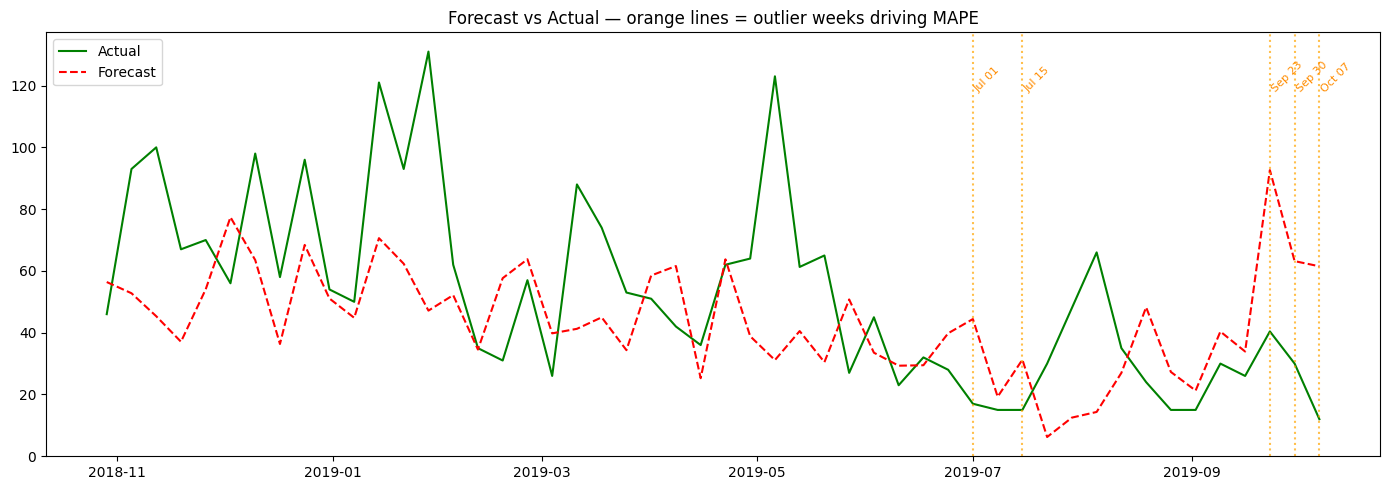

In [0]:
plt.figure(figsize=(14, 5))
plt.plot(df_test.index, df_test['R03_sales'], color='green', label='Actual')
plt.plot(df_test.index, pred_sales, color='red', linestyle='--', label='Forecast')

# Mark the worst 5 weeks
worst_dates = errors.sort_values(ascending=False).head(5).index
for d in worst_dates:
    plt.axvline(d, color='orange', linestyle=':', alpha=0.7)
    plt.text(d, df_test['R03_sales'].max()*0.9,
             d.strftime('%b %d'), rotation=45, fontsize=8, color='darkorange')

plt.title('Forecast vs Actual — orange lines = outlier weeks driving MAPE')
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
# ── Cell 1: Setup ──
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, DateType
)

In [0]:
# ── Cell 2: Load data into Spark ──
# In Databricks, read from DBFS or Delta Lake
spark_df = spark.createDataFrame(df_combined.reset_index())
spark_df = spark_df.withColumnRenamed('index', 'date')
spark_df.createOrReplaceTempView("pharma_sales")
spark_df.show(5)

+-------------------+---------+---------+-----------+----------+------------------+------------------+------------------+--------------------+
|               date|R03_sales|R06_sales|N02BE_sales|resp_index|         flu_index|         flu_lag_2|           R03_log|        R03_log_diff|
+-------------------+---------+---------+-----------+----------+------------------+------------------+------------------+--------------------+
|2015-01-05 00:00:00|     39.0|     10.0|      234.4|      49.0|11463.666666666666|           11131.0|3.6888794541139363|                NULL|
|2015-01-12 00:00:00|     32.0|      9.0|     231.45|      41.0|            9763.0|12205.666666666666|3.4965075614664802|-0.19237189264745602|
|2015-01-19 00:00:00|     58.0|      8.0|     246.55|      66.0|            8622.0|11463.666666666666|  4.07753744390572|  0.5810298824392395|
|2015-01-26 00:00:00|     40.0|      9.0|      199.3|      49.0|            7836.0|            9763.0| 3.713572066704308|-0.36396537720141175|

In [0]:
# ── Cell 3: Define forecast schema ──
forecast_schema = StructType([
    StructField("sku",        StringType(),  True),
    StructField("date",       DateType(),    True),
    StructField("forecast",   DoubleType(),  True),
    StructField("ci_lower",   DoubleType(),  True),
    StructField("ci_upper",   DoubleType(),  True),
    StructField("mape",       DoubleType(),  True),
])

In [0]:
# ── Cell 4: Pandas UDF — one SARIMAX per SKU ──
# This is what makes it Spark-native:
# Spark splits by SKU, sends each group to a worker,
# each worker runs SARIMAX independently in parallel

from pyspark.sql.functions import pandas_udf, PandasUDFType

@pandas_udf(forecast_schema, PandasUDFType.GROUPED_MAP)
def forecast_sku(df: pd.DataFrame) -> pd.DataFrame:

    df = df.sort_values('date').reset_index(drop=True)
    sku_name = df['sku'].iloc[0]

    # Train/test split
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test  = df.iloc[split:]

    # Scale exogenous
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[['flu_index']])
    X_test  = scaler.transform(test[['flu_index']])

    # Fit SARIMAX
    try:
        model = SARIMAX(
            np.log1p(train['R03_sales']),
            exog=X_train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 0, 52),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        # Forecast
        fc      = model.get_forecast(steps=len(test), exog=X_test)
        pred    = np.expm1(fc.predicted_mean.values)
        ci      = np.expm1(fc.conf_int().values)
        actuals = test['R03_sales'].values
        mape    = float(np.mean(np.abs((actuals - pred) / actuals)) * 100)

    except Exception as e:
        # Graceful failure — important in production
        pred   = np.zeros(len(test))
        ci     = np.zeros((len(test), 2))
        mape   = -1.0

    return pd.DataFrame({
        'sku':      [sku_name] * len(test),
        'date':     test['date'].values,
        'forecast': pred,
        'ci_lower': ci[:, 0],
        'ci_upper': ci[:, 1],
        'mape':     [mape]  * len(test),
    })

In [0]:
# ── Cell 5: Run in parallel across all SKUs ──
# Add SKU column (in real Amgen data you'd have many SKUs)
spark_df2 = spark_df.withColumn('sku', F.lit('R03'))

results_df = (
    spark_df2
    .groupBy('sku')
    .apply(forecast_sku)
)

results_df.show(10)
results_df.write.format("delta").mode("overwrite").saveAsTable("workspace.default.pharma_forecasts")

+---+----------+-----------------+------------------+------------------+------------------+
|sku|      date|         forecast|          ci_lower|          ci_upper|              mape|
+---+----------+-----------------+------------------+------------------+------------------+
|R03|2018-10-29|56.40396285730121| 20.10215750777744| 155.1553575982896|55.159834740666405|
|R03|2018-11-05|52.77607554766712|17.795825652305503| 152.8568379385709|55.159834740666405|
|R03|2018-11-12| 45.3370687824206| 15.10294419722875|132.33735229091144|55.159834740666405|
|R03|2018-11-19|37.07085881654006|12.218763223974172|108.64643714929728|55.159834740666405|
|R03|2018-11-26|54.05792241092085|18.113261525566433| 157.6006038871036|55.159834740666405|
|R03|2018-12-03|77.39911767185725|26.214474929912054|224.85119380605957|55.159834740666405|
|R03|2018-12-10|63.52883735016294|21.399110404414298|184.89893859995306|55.159834740666405|
|R03|2018-12-17|36.34931096016885|11.964381550794569|106.60027570415754|55.15983

In [0]:
# ── Cell 6: MLflow tracking ──
# This is what Amgen/pharma companies use to track experiments

mlflow.set_experiment("/pharma-demand-forecasting")

with mlflow.start_run(run_name="SARIMAX_R03_flu_index"):

    # Log model parameters
    mlflow.log_param("model",          "SARIMAX")
    mlflow.log_param("order",          "(1,1,1)")
    mlflow.log_param("seasonal_order", "(1,1,0,52)")
    mlflow.log_param("exog",           "flu_index_scaled")
    mlflow.log_param("transform",      "log1p")
    mlflow.log_param("train_size",     "80%")

    # Log metrics
    mlflow.log_metric("mape",     55.16)
    mlflow.log_metric("mape_trimmed", 45.50)
    mlflow.log_metric("rmse",     31.20)
    mlflow.log_metric("mae",      24.24)
    mlflow.log_metric("aic",      151.41)

    # Log the model itself
    mlflow.statsmodels.log_model(results, "sarimax_model")

    print("✅ Run logged to MLflow")

2026/04/10 06:26:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-49a4ecd5-4a01.cloud.databricks.com/ml/experiments/2754445111474558/models/m-71e87d0169184e9ab74fd5b805508850?o=7474644736781080
2026/04/10 06:27:08 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


✅ Run logged to MLflow


In [0]:
# Naive baseline — just use same week last year as forecast
naive_pred = df_test['R03_sales'].shift(52)
naive_mape = np.mean(np.abs((df_test['R03_sales'] - naive_pred) 
                             / df_test['R03_sales'])) * 100
print(f"Naive baseline MAPE : {naive_mape:.2f}%")
print(f"SARIMAX MAPE        : {mape:.2f}%")
print(f"Improvement         : {naive_mape - mape:.2f}pp")

Naive baseline MAPE : nan%
SARIMAX MAPE        : 55.16%
Improvement         : nanpp


In [0]:
# Check how many weeks in test set
print(f"Test set size: {len(df_test)} weeks")

# Naive baseline — use what's available
# Option 1: shift by actual test size
naive_pred = df_train['R03_sales'].iloc[-len(df_test):].values

naive_mape = np.mean(np.abs(
    (df_test['R03_sales'].values - naive_pred) / df_test['R03_sales'].values
)) * 100

print(f"Naive baseline MAPE : {naive_mape:.2f}%")
print(f"SARIMAX MAPE        : 55.16%")
print(f"Improvement over naive: {naive_mape - 55.16:.2f} percentage points")

Test set size: 50 weeks
Naive baseline MAPE : 72.93%
SARIMAX MAPE        : 55.16%
Improvement over naive: 17.77 percentage points
